# Time Evolution of a Burning/Cooling Front

We construct a static random velocity field and advect a reacting scalar $\theta$ through it using an explicit RK3 method. We then examine the time evolution in three regimes: diffusive, passive-scalar/turbulent, and cooling/burning.

Our system is represented by the equation

$$ \partial_t \theta + \mathbf{u} \cdot \nabla \theta - \chi \Delta \theta = S, \qquad \text{where $S$ is the source term}. $$

The sign of $S$ determines whether the front is burning or cooling.

In [13]:
# %pip install scipy scikit-image
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (7, 4.2)

# simulation size
NT = 128
ASPECT = 2
print(f'grid {ASPECT*NT} x {NT} (aspect {ASPECT}:1)')

grid 256 x 128 (aspect 2:1)


## Velocity Setup

Our velocity field is a 2D static Gaussian random field built in Fourier space. We do this to simulate turbulence, ensure the field is incompressible, and follow the Kolmogorov energy spectrum for turbulence $(E(k) \propto k^{-5/3})$

We begin by taking the curl of a scalar streamfunction, $\psi$, to get an incompressible velocity field: $u_x = \dfrac{\partial \psi}{\partial y}, \, u_y = -\dfrac{\partial \psi}{\partial x}$.

In Fourier space, $\hat u_x (\vec{k}) = ik_y\hat\psi (\vec{k}), \, \hat u_y (\vec{k}) = -ik_x\hat\psi(\vec{k})$.

We denote the standard Gaussian white noise by $W(\vec{k})$. $\hat W$ is the FT of the white noise.

In Fourier space, the streamfunction is $\hat\psi (\vec{k}) = A(|\vec{k}|) \hat W (\vec{k})$, where $A(k)$ is a radial filter that enforces the desired turbulence/roughness.

$$A(k) = 
 \begin{cases}
    k^{-7/3} \qquad k_\text{min} \leq k \leq k_\text{max} \\
    0 \qquad \text{otherwise}
 \end{cases}$$
$k_\text{min}$ and $k_\text{max}$ are determined by the size of the largest and smallest eddies.

To obtain the velocity field in the Cartesian grid, we pass $\hat u_x$ and $\hat u_y$ through an inverse FFT.

$$u_x(x,y) = \mathcal{F}^{-1} [ik_y\hat\psi (\vec{k})], \qquad u_y(x,y) = 
\mathcal{F}^{-1} [-ik_x\hat\psi(\vec{k})]$$

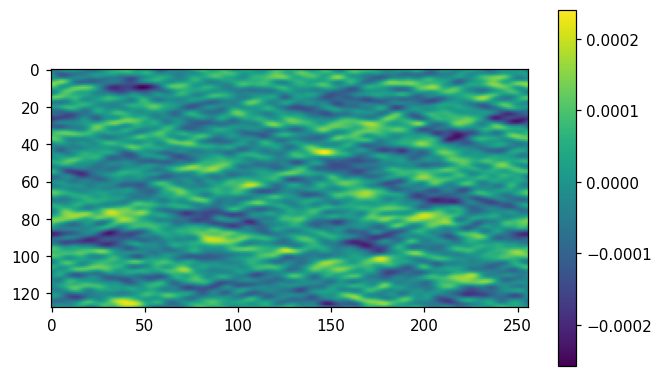

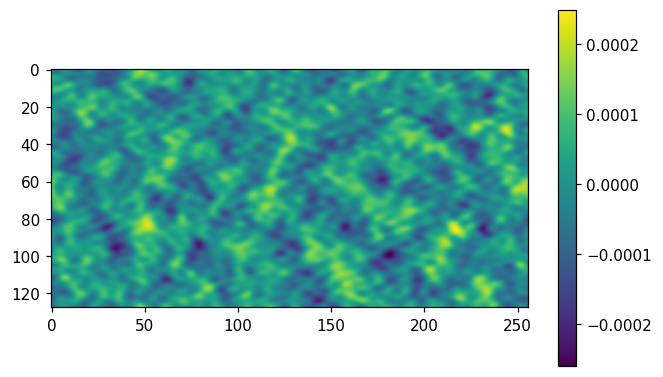

In [14]:
def make_velocity(nx, ny, Lx, Ly, kmin, kmax, seed=None):
    rng = np.random.default_rng(seed)

    kx = 2 * np.pi * np.fft.fftfreq(nx, d=Lx / nx)
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=Ly / ny)
    KX, KY = np.meshgrid(kx, ky)

    K = np.sqrt(KX**2 + KY**2)

    W = rng.standard_normal((ny, nx)) + 1j * rng.standard_normal((ny, nx))

    A = np.zeros_like(K)
    mask  = (K >= kmin) & (K <= kmax)
    A[mask] = K[mask]**(-7/3)

    A[K == 0] = 0.0

    psi_hat = A * W

    ux_hat = 1j * KY * psi_hat
    uy_hat = -1j * KX * psi_hat

    ux = np.fft.ifft2(ux_hat).real
    uy = np.fft.ifft2(uy_hat).real

    return ux, uy

ux, uy = make_velocity(nx=ASPECT*NT, ny=NT, Lx=10, Ly=10, kmin=2, kmax=20)

plt.imshow(ux)
plt.colorbar()
plt.show()

plt.imshow(uy)
plt.colorbar()
plt.show()

## Explicit RK3 Method

We want to advance $\theta$ through time, and we do this via a RK3 scheme. We begin by rewriting the equation as

$$\partial_t \theta = S - \mathbf{u} \cdot \nabla \theta + \chi \Delta \theta$$

Denote the RHS by $R(\theta)$. The RK3 scheme is implemented as follows:

$$
\theta^{(1)}=\theta^n+\Delta t\,R(\theta^n),\quad
\theta^{(2)}=\tfrac34\theta^n+\tfrac14\!\big(\theta^{(1)}+\Delta t\,R(\theta^{(1)})\big),\quad
\theta^{n+1}=\tfrac13\theta^n+\tfrac23\!\big(\theta^{(2)}+\Delta t\,R(\theta^{(2)})\big).
$$

The time-step, $\Delta t$, is limited by both an adevective and diffusive CFL condition:

$$\Delta t \le \min\!\Big(\underbrace{C_a\,\tfrac{\Delta x}{|\mathbf u|_{\max}}}_{\text{advective}},\;
\underbrace{C_d\,\tfrac{\Delta x^2}{\chi}}_{\text{diffusive}}\Big),$$

## Pseudo-Spectral Method

To advect the scalar field $\theta$, we must evaluate the nonlinear advection term $\mathbf{u} \cdot \nabla \theta$ and the diffusion term $\chi \Delta \theta$.

Finite difference methods evaluate these gradients on the physical grid, which introduces numerical dispersion and smearing. The pseudo-spectral method solves this by calculating all spatial derivatives in Fourier space, where derivatives become exact algebraic multiplications:

$$\partial_x \theta \implies ik_x \hat{\theta}, \qquad \Delta \theta \implies -(k_x^2 + k_y^2)\hat{\theta}$$

While the derivatives are computed in frequency space, we use the Inverse Fast Fourier Transform to bring the exact gradients back to physical space to multiply them by the velocity field. Doing this multiplication in physical space takes $\mathcal{O}(N \log N)$ operations via FFTs, which is much faster than doing the exact spectral convolution in Fourier space $\mathcal{O}(N^2)$.

Running Pe=0.5, Da=0.1
chi: 40.0000 | S_0: 0.0050 | dt: 0.000031
Running Pe=200.0, Da=0.1
chi: 0.1000 | S_0: 0.0050 | dt: 0.012207
Running Pe=200.0, Da=5.0
chi: 0.1000 | S_0: 0.2500 | dt: 0.012207


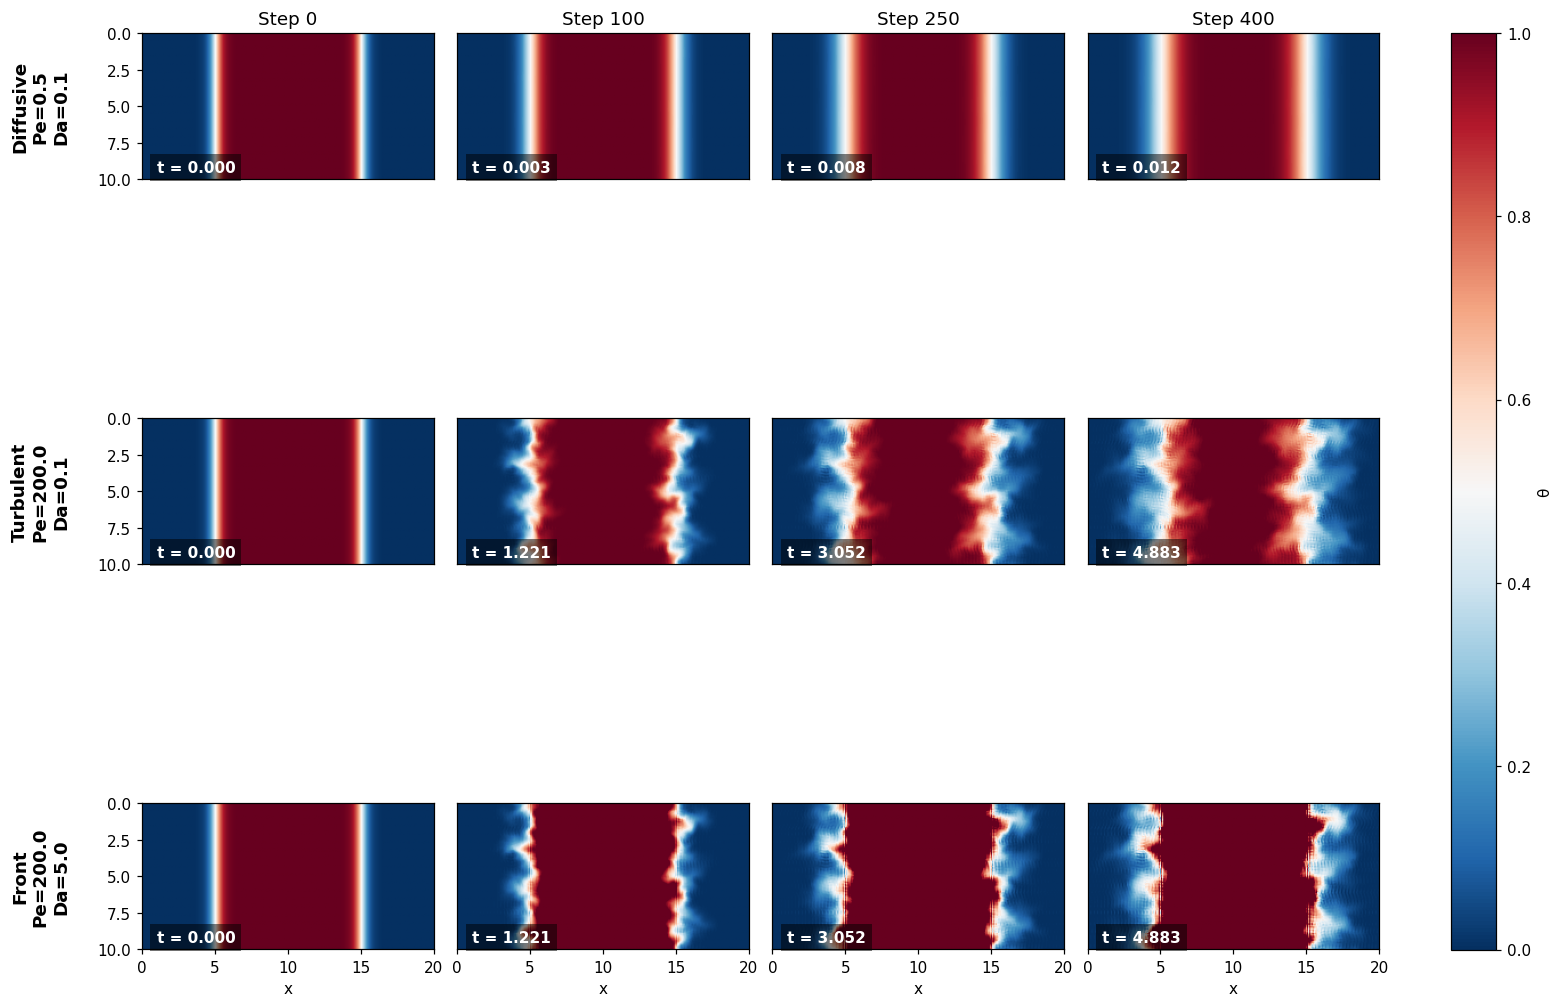

In [ ]:
# psuedo-spectral method
def compute_rhs(theta, ux, uy, KX, KY, K_sq, chi, S, dealias_mask):
    theta_hat = np.fft.fft2(theta) * dealias_mask
    dtheta_dx = np.fft.ifft2(1j * KX * theta_hat).real
    dtheta_dy = np.fft.ifft2(1j * KY * theta_hat).real
    laplacian = np.fft.ifft2(-K_sq * theta_hat).real
    return S - (ux * dtheta_dx + uy * dtheta_dy) + chi * laplacian

# rk3 setup
def rk3_step(theta, ux, uy, KX, KY, K_sq, chi, S, dt, dealias_mask):
    rhs1 = compute_rhs(theta, ux, uy, KX, KY, K_sq, chi, S, dealias_mask)
    theta1 = theta + dt * rhs1

    rhs2 = compute_rhs(theta1, ux, uy, KX, KY, K_sq, chi, S, dealias_mask)
    theta2 = 0.75 * theta + 0.25 * (theta1 + dt * rhs2)

    rhs3 = compute_rhs(theta2, ux, uy, KX, KY, K_sq, chi, S, dealias_mask)
    return (1.0 / 3.0) * theta + (2.0 / 3.0) * (theta2 + dt * rhs3)

#simulator
def simulator():
    dgsdfg
    return outputs

# global setup
nx, ny = ASPECT * NT, NT
Lx, Ly = 20.0, 10.0
dx = Lx / nx

kx = 2 * np.pi * np.fft.fftfreq(nx, d=Lx / nx)
ky = 2 * np.pi * np.fft.fftfreq(ny, d=Ly / ny)
KX, KY = np.meshgrid(kx, ky)
K_sq = KX**2 + KY**2

kx_max, ky_max = np.max(np.abs(kx)), np.max(np.abs(ky))
dealias_mask = (np.abs(KX) < (2.0/3.0) * kx_max) & (np.abs(KY) < (2.0/3.0) * ky_max)

ux, uy = make_velocity(nx, ny, Lx, Ly, kmin=2, kmax=20, seed=42)

# velocity normalization
U_rms_raw = np.sqrt(np.mean(ux**2 + uy**2))
ux = ux / U_rms_raw
uy = uy / U_rms_raw

U_rms = np.sqrt(np.mean(ux**2 + uy**2)) # Now exactly 1.0
max_u = np.max(np.sqrt(ux**2 + uy**2))

x = np.linspace(0, Lx, nx, endpoint=False)
y = np.linspace(0, Ly, ny, endpoint=False)
X, Y = np.meshgrid(x, y)

lo, hi = Lx * 0.25, Lx * 0.75
width = 0.5

# parameters for sim
Pe_list = [0.5, 200.0, 200.0]
Da_list = [0.1, 0.1, 5.0]

n_steps = 400
save_steps = [0, 100, 250, 400]
all_results = []

for Pe, Da in zip(Pe_list, Da_list):
    print(f"Running Pe={Pe}, Da={Da}")

    chi = (U_rms * Lx) / Pe
    S_0 = (Da * U_rms) / Lx

    # initial condition
    theta = np.clip(0.5 * (np.tanh((X - lo) / width) - np.tanh((X - hi) / width)), 0, 1)
    S = np.where((X >= lo) & (X <= hi), S_0, 0.0)

    # calc stable dt
    dt_adv = 0.5 * (dx / max_u)
    dt_dif = 0.2 * (dx**2 / chi)
    dt = min(dt_adv, dt_dif)

    print(f"chi: {chi:.4f} | S_0: {S_0:.4f} | dt: {dt:.6f}")

    snapshots = {'dt': dt}
    for step in range(n_steps + 1):
        if step in save_steps:
            snapshots[step] = theta.copy()
        if step < n_steps:
            theta = rk3_step(theta, ux, uy, KX, KY, K_sq, chi, S, dt, dealias_mask)

    all_results.append(snapshots)

# plots
num_runs = len(Pe_list)
num_snaps = len(save_steps)
regime_names = ["Diffusive", "Turbulent", "Front"]

fig, axes = plt.subplots(num_runs, num_snaps, figsize=(14, 3.5 * num_runs), constrained_layout=True)

for row_idx, (Pe, Da, name) in enumerate(zip(Pe_list, Da_list, regime_names)):
    snapshots = all_results[row_idx]
    dt = snapshots['dt']

    for col_idx, step in enumerate(save_steps):
        ax = axes[row_idx, col_idx]
        im = ax.imshow(snapshots[step], extent=[0, Lx, Ly, 0], origin='upper', cmap='RdBu_r', vmin=0, vmax=1)

        if row_idx == 0:
            ax.set_title(f'Step {step}')

        if col_idx == 0:
            ax.set_ylabel(f'{name}\nPe={Pe}\nDa={Da}\n', fontsize=12, fontweight='bold')
        else:
            ax.set_yticks([])

        ax.text(0.05, 0.05, f't = {step*dt:.3f}', transform=ax.transAxes,
                color='white', fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

        if row_idx == num_runs - 1:
            ax.set_xlabel('x')
        else:
            ax.set_xticks([])

fig.colorbar(im, ax=axes, label='θ', location='right', shrink=0.8)
plt.show()

## Velocity Normalization

Our synthetic turbulent velocity field is generated in Fourier space using random Gaussian noise filtered by a Kolmogorov cascade ($E(k) \propto k^{-5/3}$). When transforming this field back to physical space, the standard IFFT algorithm scales the amplitude down by a factor of the total grid size ($N_x \times N_y$), resulting in an arbitrarily tiny raw velocity. To make the physics meaningful, we normalize the field by dividing it by its root-mean-square magnitude:

$$\mathbf{u}_{\text{norm}} = \frac{\mathbf{u}}{\sqrt{\langle |\mathbf{u}|^2 \rangle}}$$

This forces $U_{\text{rms}} = 1.0$. This scaling preserves the divergence-free condition ($\nabla \cdot \mathbf{u} = 0$) and the $k^{-5/3}$ turbulent energy distribution. It also anchors our dimensionless numbers ($Pe, Da$) and establishes a standard timescale where one unit of simulation time ($t=1$) equals the time it takes an average eddy to traverse one unit of spatial distance.

## 2/3 De-aliasing Rule

Because we evaluate the nonlinear multiplication $\mathbf{u} \cdot \nabla \theta$ in physical space, we encounter spectral aliasing. We multiply two signals, and so their frequencies add together. If two high-frequency waves interact, their product can exceed the maximum frequency the grid can resolve. The math library misinterprets these unresolvable high frequencies as low-frequency waves, causing artificial energy to potentially crash the solver.

We can apply orszag's 2/3 rule to prevent this:

$$\hat{\theta}(k_x, k_y) = 0 \quad \text{for} \quad |k| > \frac{2}{3}k_{\max}$$

By zeroing out the top 1/3 of the wavenumber spectrum at the beginning of every sub-step, the maximum frequency generated by nonlinear multiplication is capped at $\frac{4}{3} k_{\max}$. While this excess energy does alias, it lands in the upper-third region that we erase on the next step. We only sacrifice a small amount of spatial resolution to guarantee mathematical stability.